# Exploración inicial del dataset – Smart Warehouse GridWorld

**Proyecto:** Comparación de SARSA, Q-Learning y Monte Carlo en un gemelo digital simplificado de un almacén inteligente.

**Integrantes**

Carlos Sepúlveda Navarrete  

René Yáñez Navarrete


## 1. Carga de librerías y dataset

Se ejecuta el notebook desde la misma carpeta donde se encuentran los archivos `smart_warehouse_cells.csv`, `smart_warehouse_transitions.csv` y `smart_warehouse_maps.json`.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

cells_path = Path('smart_warehouse_cells.csv')
trans_path = Path('smart_warehouse_transitions.csv')
maps_path = Path('smart_warehouse_maps.json')

cells_df = pd.read_csv(cells_path)
trans_df = pd.read_csv(trans_path)

with open(maps_path, 'r', encoding='utf-8') as f:
    maps_data = json.load(f)

maps = maps_data['mapas']

print('smart_warehouse_cells.csv       →', cells_df.shape)
print('smart_warehouse_transitions.csv →', trans_df.shape)
print('Almacenes disponibles:', list(maps.keys()))

smart_warehouse_cells.csv       → (189, 13)
smart_warehouse_transitions.csv → (528, 13)
Almacenes disponibles: ['almacen_5x5_baja', 'almacen_8x8_media', 'almacen_10x10_alta']


## 2. Vista inicial de los archivos

In [2]:
display(cells_df.head())
display(trans_df.head())

,almacen_id,filas_almacen,columnas_almacen,estado_id,fila,columna,simbolo_celda,tipo_zona,descripcion_zona,recompensa_entrada,es_terminal,es_obstaculo,max_pasos_episodio
0,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,Posición inicial del robot autónomo dentro del...,-1.0,False,False,50
1,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50
2,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c2,0,2,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50
3,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c3,0,3,X,estanteria,Estantería o zona bloqueada no transitable.,NaN,False,True,50
4,almacen_5x5_baja,5,5,almacen_5x5_baja_r0_c4,0,4,.,pasillo_libre,Pasillo libre transitable.,-1.0,False,False,50


,almacen_id,estado_id,fila,columna,accion,siguiente_estado_id,siguiente_fila,siguiente_columna,siguiente_simbolo_celda,siguiente_tipo_zona,recompensa,terminado,evento
0,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,arriba,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,-5,False,fuera_del_almacen
1,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,abajo,almacen_5x5_baja_r1_c0,1,0,.,pasillo_libre,-1,False,movimiento_por_pasillo
2,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,izquierda,almacen_5x5_baja_r0_c0,0,0,S,inicio_robot,-5,False,fuera_del_almacen
3,almacen_5x5_baja,almacen_5x5_baja_r0_c0,0,0,derecha,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,-1,False,movimiento_por_pasillo
4,almacen_5x5_baja,almacen_5x5_baja_r0_c1,0,1,arriba,almacen_5x5_baja_r0_c1,0,1,.,pasillo_libre,-5,False,fuera_del_almacen


## 3. Información general del dataset

Se revisan tipos de variables, cantidad de registros y estructura general de cada archivo.

In [3]:
print('=== CELDAS DEL ALMACÉN ===')
cells_df.info()

print()
print('=== TRANSICIONES ESTADO-ACCIÓN ===')
trans_df.info()

=== CELDAS DEL ALMACÉN ===
<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   almacen_id          189 non-null    str    
 1   filas_almacen       189 non-null    int64  
 2   columnas_almacen    189 non-null    int64  
 3   estado_id           189 non-null    str    
 4   fila                189 non-null    int64  
 5   columna             189 non-null    int64  
 6   simbolo_celda       189 non-null    str    
 7   tipo_zona           189 non-null    str    
 8   descripcion_zona    189 non-null    str    
 9   recompensa_entrada  132 non-null    float64
 10  es_terminal         189 non-null    bool   
 11  es_obstaculo        189 non-null    bool   
 12  max_pasos_episodio  189 non-null    int64  
dtypes: bool(2), float64(1), int64(5), str(5)
memory usage: 32.9 KB

=== TRANSICIONES ESTADO-ACCIÓN ===
<class 'pandas.DataFrame'>
RangeIndex: 5

## 4. Valores faltantes

En este dataset, las estanterías no son estados visitables. Por eso, la recompensa de entrada puede aparecer vacía en dichas celdas.

In [4]:
print('Valores faltantes en celdas:')
display(cells_df.isnull().sum())

print('Valores faltantes en transiciones:')
display(trans_df.isnull().sum())

Valores faltantes en celdas:


almacen_id             0
filas_almacen          0
columnas_almacen       0
estado_id              0
fila                   0
columna                0
simbolo_celda          0
tipo_zona              0
descripcion_zona       0
recompensa_entrada    57
es_terminal            0
es_obstaculo           0
max_pasos_episodio     0
dtype: int64

Valores faltantes en transiciones:


almacen_id                 0
estado_id                  0
fila                       0
columna                    0
accion                     0
siguiente_estado_id        0
siguiente_fila             0
siguiente_columna          0
siguiente_simbolo_celda    0
siguiente_tipo_zona        0
recompensa                 0
terminado                  0
evento                     0
dtype: int64

## 5. Distribución de zonas del almacén

Se analiza cuántas celdas corresponden a pasillos, estanterías, zonas congestionadas, inicio del robot y zona de entrega.

tipo_zona
pasillo_libre         119
estanteria             57
zona_congestionada      7
inicio_robot            3
zona_entrega            3
Name: count, dtype: int64

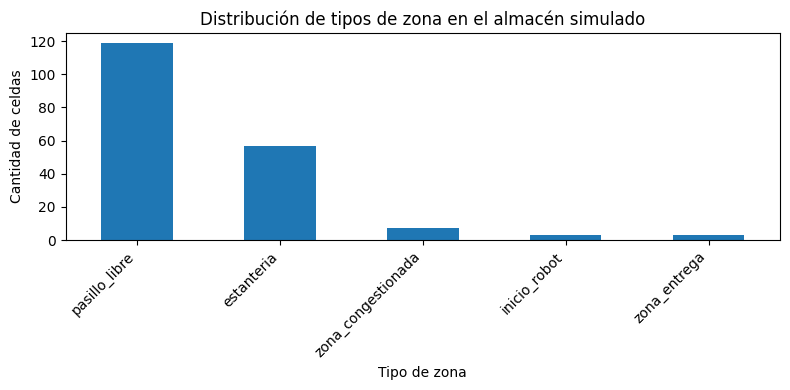

In [5]:
dist_zonas = cells_df['tipo_zona'].value_counts()
display(dist_zonas)

ax = dist_zonas.plot(kind='bar', figsize=(8, 4))
ax.set_title('Distribución de tipos de zona en el almacén simulado')
ax.set_xlabel('Tipo de zona')
ax.set_ylabel('Cantidad de celdas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Distribución por mapa

El dataset contiene tres almacenes simulados con distinta complejidad: baja, media y alta.

tipo_zona,estanteria,inicio_robot,pasillo_libre,zona_congestionada,zona_entrega
almacen_id,,,,,
almacen_10x10_alta,33,1,62,3,1
almacen_5x5_baja,6,1,16,1,1
almacen_8x8_media,18,1,41,3,1


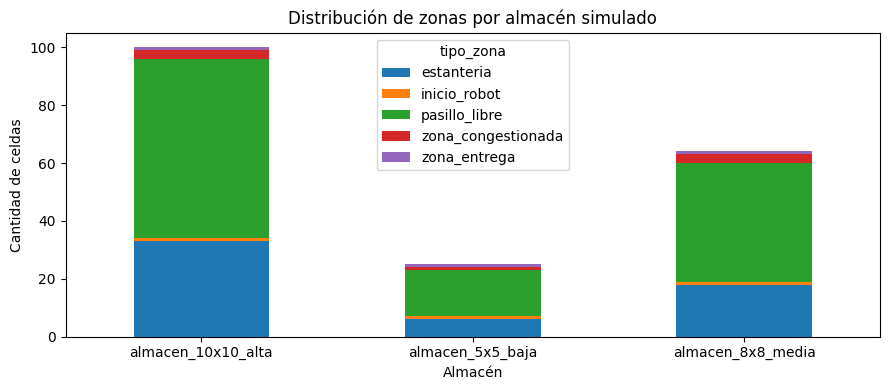

In [6]:
resumen_por_mapa = pd.crosstab(cells_df['almacen_id'], cells_df['tipo_zona'])
display(resumen_por_mapa)

ax = resumen_por_mapa.plot(kind='bar', stacked=True, figsize=(9, 4))
ax.set_title('Distribución de zonas por almacén simulado')
ax.set_xlabel('Almacén')
ax.set_ylabel('Cantidad de celdas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Eventos disponibles en las transiciones

Cada transición indica qué ocurre cuando el robot ejecuta una acción desde una celda determinada.

evento
movimiento_por_pasillo      260
choque_con_estanteria       151
fuera_del_almacen            75
entra_zona_congestionada     18
estado_terminal              12
vuelve_inicio_robot           6
llega_zona_entrega            6
Name: count, dtype: int64

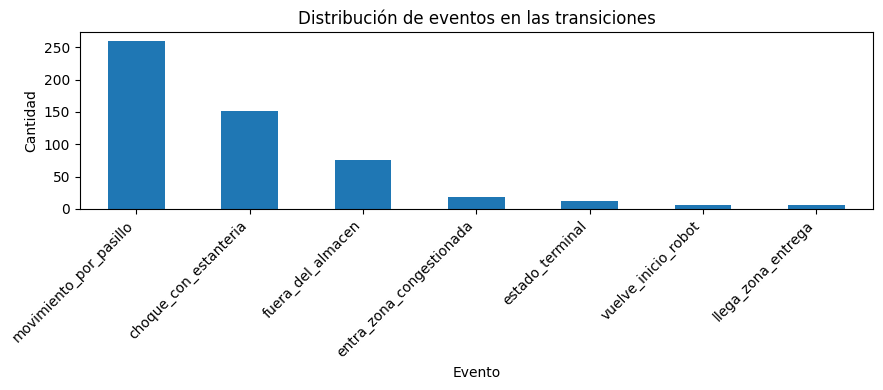

In [7]:
eventos = trans_df['evento'].value_counts()
display(eventos)

ax = eventos.plot(kind='bar', figsize=(9, 4))
ax.set_title('Distribución de eventos en las transiciones')
ax.set_xlabel('Evento')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Visualización de los almacenes simulados

La siguiente función permite visualizar los mapas como grillas. La interpretación es:

- `S`: inicio del robot.
- `G`: zona de entrega.
- `X`: estantería u obstáculo.
- `R`: zona congestionada.
- `.`: pasillo libre.

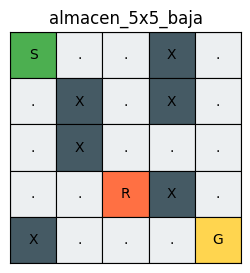

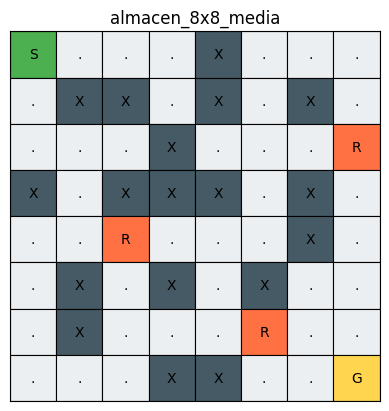

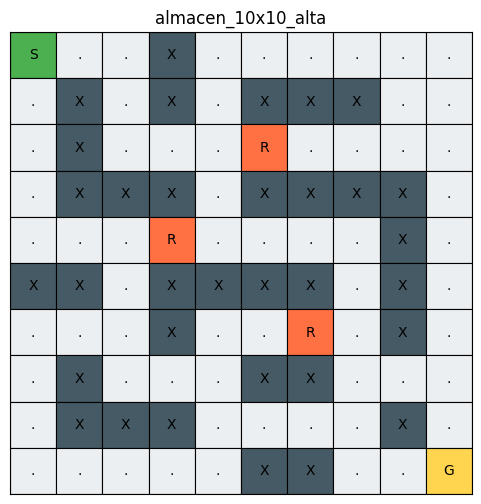

In [8]:
def visualizar_almacen(nombre_mapa, mapa):
    colores = {
        'S': '#4CAF50',  # inicio robot
        'G': '#FFD54F',  # zona entrega
        'X': '#455A64',  # estantería
        'R': '#FF7043',  # zona congestionada
        '.': '#ECEFF1'   # pasillo libre
    }
    etiquetas = {
        'S': 'Inicio robot',
        'G': 'Entrega',
        'X': 'Estantería',
        'R': 'Congestión',
        '.': 'Pasillo'
    }

    filas = len(mapa)
    columnas = len(mapa[0])
    fig, ax = plt.subplots(figsize=(columnas * 0.6, filas * 0.6))

    for i, fila in enumerate(mapa):
        for j, simbolo in enumerate(fila):
            rect = plt.Rectangle((j, filas - i - 1), 1, 1,
                                 facecolor=colores.get(simbolo, 'white'),
                                 edgecolor='black', linewidth=0.8)
            ax.add_patch(rect)
            ax.text(j + 0.5, filas - i - 0.5, simbolo,
                    ha='center', va='center', fontsize=10)

    ax.set_xlim(0, columnas)
    ax.set_ylim(0, filas)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(nombre_mapa)
    plt.show()

for nombre, mapa in maps.items():
    visualizar_almacen(nombre, mapa)

## 9. Resumen 

In [9]:
print('Resumen del dataset actualizado')
print('Cantidad de almacenes simulados:', cells_df['almacen_id'].nunique())
print('Total de celdas:', len(cells_df))
print('Total de transiciones:', len(trans_df))
print('Tipos de zona:', ', '.join(cells_df['tipo_zona'].unique()))
print('Acciones disponibles:', ', '.join(trans_df['accion'].unique()))
print()
print('Distribución global:')
print(cells_df['tipo_zona'].value_counts())

Resumen del dataset actualizado
Cantidad de almacenes simulados: 3
Total de celdas: 189
Total de transiciones: 528
Tipos de zona: inicio_robot, pasillo_libre, estanteria, zona_congestionada, zona_entrega
Acciones disponibles: arriba, abajo, izquierda, derecha

Distribución global:
tipo_zona
pasillo_libre         119
estanteria             57
zona_congestionada      7
inicio_robot            3
zona_entrega            3
Name: count, dtype: int64


## 10. Preparación del entorno para Q-Learning

Desde esta parte se agrega el primer experimento del Avance 2. Se usa el almacén de baja dificultad para comprobar que el agente pueda aprender una ruta funcional antes de probar escenarios más grandes.


In [10]:
# Selección del escenario inicial para el modelo base
almacen_id = 'almacen_5x5_baja'

cells_map = cells_df[cells_df['almacen_id'] == almacen_id].copy()
trans_map = trans_df[trans_df['almacen_id'] == almacen_id].copy()

acciones = ['arriba', 'abajo', 'izquierda', 'derecha']
estados_validos = sorted(cells_map[~cells_map['es_obstaculo']]['estado_id'].tolist())
estado_inicial = cells_map.loc[cells_map['simbolo_celda'] == 'S', 'estado_id'].iloc[0]
estado_meta = cells_map.loc[cells_map['simbolo_celda'] == 'G', 'estado_id'].iloc[0]
max_pasos = int(cells_map['max_pasos_episodio'].max())

transiciones = {
    (fila.estado_id, fila.accion): (
        fila.siguiente_estado_id,
        float(fila.recompensa),
        bool(fila.terminado),
        fila.evento
    )
    for fila in trans_map.itertuples(index=False)
}

print('Escenario utilizado:', almacen_id)
print('Estados válidos:', len(estados_validos))
print('Acciones disponibles:', acciones)
print('Estado inicial:', estado_inicial)
print('Estado meta:', estado_meta)
print('Máximo de pasos por episodio:', max_pasos)


Escenario utilizado: almacen_5x5_baja
Estados válidos: 19
Acciones disponibles: ['arriba', 'abajo', 'izquierda', 'derecha']
Estado inicial: almacen_5x5_baja_r0_c0
Estado meta: almacen_5x5_baja_r4_c4
Máximo de pasos por episodio: 50


## 11. Modelo base: Q-Learning

Se implementa Q-Learning como primer modelo base. La idea es partir con una referencia simple y funcional para luego comparar con SARSA y Monte Carlo.


In [11]:
import numpy as np
import random

# Parámetros iniciales
episodios = 500
alpha = 0.1      # tasa de aprendizaje
gamma = 0.9      # importancia de recompensas futuras
epsilon = 0.2    # probabilidad de explorar
semilla = 42

random.seed(semilla)
np.random.seed(semilla)

# Tabla Q inicial: un valor por cada combinación estado-acción
Q = {
    (estado, accion): 0.0
    for estado in estados_validos
    for accion in acciones
}

def elegir_accion(estado, epsilon_actual):
    # Exploración: probar una acción al azar
    if random.random() < epsilon_actual:
        return random.choice(acciones)

    # Explotación: usar la mejor acción conocida
    valores = [Q[(estado, accion)] for accion in acciones]
    valor_maximo = max(valores)
    mejores_acciones = [accion for accion, valor in zip(acciones, valores) if valor == valor_maximo]
    return random.choice(mejores_acciones)

historial = []

for episodio in range(1, episodios + 1):
    estado = estado_inicial
    recompensa_total = 0
    pasos = 0
    exito = False

    for _ in range(max_pasos):
        accion = elegir_accion(estado, epsilon)
        siguiente_estado, recompensa, terminado, evento = transiciones[(estado, accion)]

        recompensa_total += recompensa
        pasos += 1

        max_q_siguiente = max(Q[(siguiente_estado, a)] for a in acciones)
        Q[(estado, accion)] = Q[(estado, accion)] + alpha * (
            recompensa + gamma * max_q_siguiente - Q[(estado, accion)]
        )

        estado = siguiente_estado

        if terminado:
            exito = True
            break

    historial.append({
        'episodio': episodio,
        'recompensa_acumulada': recompensa_total,
        'pasos': pasos,
        'exito': exito
    })

resultados_qlearning = pd.DataFrame(historial)
display(resultados_qlearning.head())
display(resultados_qlearning.tail())


,episodio,recompensa_acumulada,pasos,exito
0,1,-144.0,50,False
1,2,45.0,32,True
2,3,67.0,13,True
3,4,-82.0,50,False
4,5,-90.0,50,False


,episodio,recompensa_acumulada,pasos,exito
495,496,84.0,8,True
496,497,63.0,12,True
497,498,93.0,8,True
498,499,84.0,13,True
499,500,93.0,8,True


## 12. Resultados iniciales

Se resumen las primeras métricas del entrenamiento: recompensa acumulada, cantidad de pasos y tasa de éxito. Estos valores servirán como comparación para los otros algoritmos.


In [12]:
resumen_resultados = pd.DataFrame({
    'Métrica': [
        'Recompensa promedio total',
        'Recompensa promedio últimos 100 episodios',
        'Pasos promedio total',
        'Pasos promedio últimos 100 episodios',
        'Tasa de éxito total',
        'Tasa de éxito últimos 100 episodios'
    ],
    'Valor': [
        resultados_qlearning['recompensa_acumulada'].mean(),
        resultados_qlearning.tail(100)['recompensa_acumulada'].mean(),
        resultados_qlearning['pasos'].mean(),
        resultados_qlearning.tail(100)['pasos'].mean(),
        resultados_qlearning['exito'].mean(),
        resultados_qlearning.tail(100)['exito'].mean()
    ]
})

display(resumen_resultados)


,Métrica,Valor
0,Recompensa promedio total,84.680
1,Recompensa promedio últimos 100 episodios,85.180
2,Pasos promedio total,10.770
3,Pasos promedio últimos 100 episodios,10.260
4,Tasa de éxito total,0.994
5,Tasa de éxito últimos 100 episodios,1.000


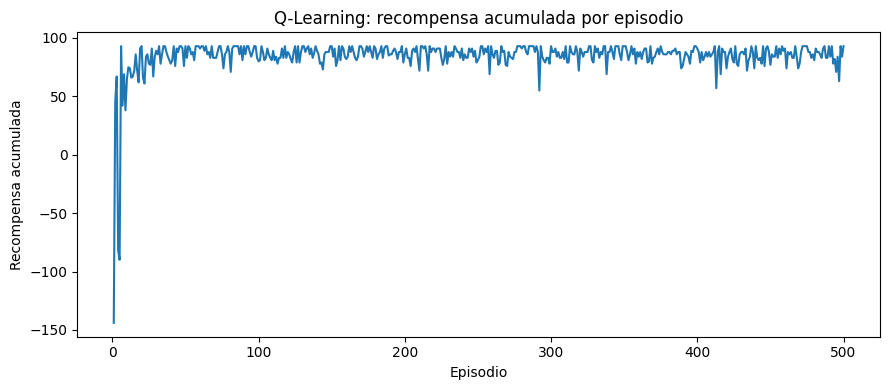

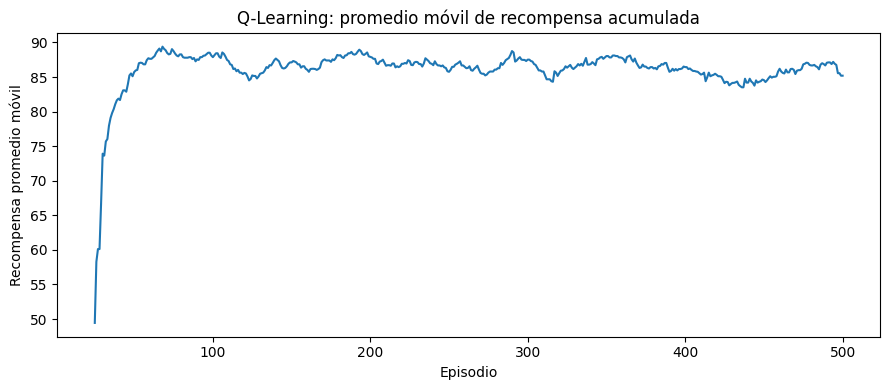

In [13]:
# Gráfico de recompensa acumulada por episodio
ax = resultados_qlearning.plot(
    x='episodio',
    y='recompensa_acumulada',
    figsize=(9, 4),
    legend=False
)
ax.set_title('Q-Learning: recompensa acumulada por episodio')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa acumulada')
plt.tight_layout()
plt.show()

# Promedio móvil para observar mejor la tendencia
resultados_qlearning['recompensa_promedio_movil'] = resultados_qlearning['recompensa_acumulada'].rolling(25).mean()
ax = resultados_qlearning.plot(
    x='episodio',
    y='recompensa_promedio_movil',
    figsize=(9, 4),
    legend=False
)
ax.set_title('Q-Learning: promedio móvil de recompensa acumulada')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa promedio móvil')
plt.tight_layout()
plt.show()


## 13. Política aprendida

Con la tabla Q entrenada se obtiene la mejor acción para cada celda visitable del almacén. Esto permite revisar visualmente la política que aprendió el agente.


In [14]:
flechas = {
    'arriba': '↑',
    'abajo': '↓',
    'izquierda': '←',
    'derecha': '→'
}

def mejor_accion(estado):
    valores = [Q[(estado, accion)] for accion in acciones]
    return acciones[int(np.argmax(valores))]

politica = cells_map[['fila', 'columna', 'estado_id', 'simbolo_celda', 'tipo_zona']].copy()

def simbolo_politica(fila):
    if fila['simbolo_celda'] == 'X':
        return 'X'
    if fila['simbolo_celda'] == 'S':
        return 'S'
    if fila['simbolo_celda'] == 'G':
        return 'G'
    accion = mejor_accion(fila['estado_id'])
    return flechas[accion]

politica['politica_aprendida'] = politica.apply(simbolo_politica, axis=1)

tabla_politica = politica.pivot(index='fila', columns='columna', values='politica_aprendida')
display(tabla_politica)


columna,0,1,2,3,4
fila,,,,,
0,S,→,↓,X,↓
1,↑,X,↓,X,↓
2,↓,X,→,→,↓
3,→,↓,↓,X,↓
4,X,→,→,→,G


## 14. Prueba de la ruta aprendida

Finalmente, se ejecuta una prueba usando solo la mejor acción aprendida en cada estado. Con esto se revisa si el agente logra llegar desde el inicio hasta la zona de entrega.


In [15]:
estado = estado_inicial
ruta = [estado]
recompensa_total = 0

for _ in range(max_pasos):
    accion = mejor_accion(estado)
    siguiente_estado, recompensa, terminado, evento = transiciones[(estado, accion)]
    recompensa_total += recompensa
    ruta.append(siguiente_estado)
    estado = siguiente_estado

    if terminado:
        break

print('Ruta encontrada por la política aprendida:')
for paso, estado in enumerate(ruta):
    print(paso, estado)

print('Llegó a la zona de entrega:', ruta[-1] == estado_meta)
print('Cantidad de pasos:', len(ruta) - 1)
print('Recompensa total de la ruta:', recompensa_total)


Ruta encontrada por la política aprendida:
0 almacen_5x5_baja_r0_c0
1 almacen_5x5_baja_r0_c1
2 almacen_5x5_baja_r0_c2
3 almacen_5x5_baja_r1_c2
4 almacen_5x5_baja_r2_c2
5 almacen_5x5_baja_r2_c3
6 almacen_5x5_baja_r2_c4
7 almacen_5x5_baja_r3_c4
8 almacen_5x5_baja_r4_c4
Llegó a la zona de entrega: True
Cantidad de pasos: 8
Recompensa total de la ruta: 93.0
